In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import numpy as np

# Analyse de corrélation entre les articles scrappés et le sondage Politbarometer
## Transformer les sondage en apercu annuel et normaliser

In [31]:
df = pd.read_stata('../data/Politbarometer/dataset_cumul_1977.dta',convert_categoricals=False)
df

,v1,v2,Version,doi,v3,v4,V4a,v5,v6,v7,...,v72,v73,v74,v75,v76,v77,v78,v79,v80,V81
0,2391,1.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,3,1977,2,1,1,99,...,2,2,2,5,5,0,1.640,0,3,0.000
1,2391,2.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,3,1977,2,1,2,99,...,1,2,4,5,5,0,1.670,0,3,0.000
2,2391,3.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,3,1977,2,1,1,99,...,2,3,4,5,5,0,0.650,0,3,0.000
3,2391,4.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,3,1977,2,1,98,99,...,99,0,4,5,5,0,0.820,0,3,0.000
4,2391,5.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,3,1977,2,1,1,99,...,2,3,4,5,5,0,1.670,0,3,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1046814,2391,501626.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,2,1,4,4,...,10,0,4,3,0,4,0.383,0,50,0.383
1046815,2391,501627.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,2,1,4,4,...,6,2,3,1,0,1,0.596,0,50,0.596
1046816,2391,501628.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,1,1,38,22,...,10,0,4,13,0,5,1.969,0,50,0.954
1046817,2391,501629.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,1,4,99,23,...,10,0,4,14,0,4,1.038,0,50,0.503


In [32]:
problemes_survey_df = df[['v4', 'v33']]
#votes_partie_df.loc[:,'v33'] = votes_partie_df['v33'].apply(lambda x: dict_plus_grand_problemes[x] if x in dict_plus_grand_problemes.keys() else x)

problemes_survey_df = problemes_survey_df[~problemes_survey_df['v33'].isin([0,998,999])]

total = int(problemes_survey_df['v33'].count())


pb_percentage = pd.DataFrame(problemes_survey_df.groupby('v33').size() / total)
top_20_problems = list(pb_percentage.sort_values(by=0,ascending=False)[0:20].reset_index()['v33'])
problemes_survey_df = problemes_survey_df[problemes_survey_df['v33'].isin(top_20_problems)]


total_votes_per_year = pd.DataFrame(problemes_survey_df.groupby(by=['v4']).size())

total_votes_per_year = total_votes_per_year.reset_index()


In [33]:
print(problemes_survey_df)
problemes_survey_df = pd.DataFrame(problemes_survey_df.groupby(by=['v4','v33']).size())

problemes_survey_df = problemes_survey_df.reset_index()
#votes_partie_df[0] = votes_partie_df[0] / total_votes_per_year[0]
problemes_survey_df = problemes_survey_df.set_index('v4')
total_votes_per_year = total_votes_per_year.set_index('v4')
problemes_survey_df['total'] =  total_votes_per_year
print(problemes_survey_df)
problemes_survey_df['vote percentage'] = problemes_survey_df[0] / problemes_survey_df['total'] 
#problemes_survey_df['vote percentage'] = (problemes_survey_df[0]-problemes_survey_df[0].min())/(problemes_survey_df[0].max()-problemes_survey_df[0].min())


problemes_survey_df = problemes_survey_df.reset_index()

           v4  v33
98548    1986    1
98549    1986    1
98551    1986   14
98552    1986   14
98553    1986   14
...       ...  ...
1046804  2022   15
1046806  2022   58
1046810  2022   23
1046811  2022   15
1046813  2022    5

[736872 rows x 2 columns]
      v33     0  total
v4                    
1986    1   383   2926
1986    5    47   2926
1986   10    47   2926
1986   13   110   2926
1986   14  1287   2926
...   ...   ...    ...
2022   56    43  15266
2022   58   115  15266
2022   66   747  15266
2022   77   819  15266
2022  134  3528  15266

[621 rows x 3 columns]


In [34]:
data_lines = []
for year in range(2000,2023):
    data_line = []
    data_line.append(year)
    for question_code in top_20_problems:
        pc = problemes_survey_df[(problemes_survey_df['v4'] == year) & (problemes_survey_df['v33'] == question_code)]['vote percentage']
        if(len(pc) > 0):
            pc = float(pc.iloc[0])
        else:
            pc = 0
        data_line.append(pc)
    data_lines.append(data_line)
df_survey = pd.DataFrame(data_lines)
df_survey = df_survey.set_axis(['Year'] + top_20_problems,axis = 1)
print(top_20_problems)
df_survey = df_survey.set_index('Year')
df_survey

[14, 54, 13, 134, 27, 15, 77, 1, 55, 66, 30, 5, 117, 20, 10, 23, 19, 58, 53, 56]


,14,54,13,134,27,15,77,1,55,66,30,5,117,20,10,23,19,58,53,56
Year,,,,,,,,,,,,,,,,,,,,
2000,0.604920,0.045053,0.017358,0.000000,0.065782,0.015865,0.009563,0.053731,0.002598,0.019016,0.008071,0.010503,0.000000,0.008071,0.023825,0.023549,0.012548,0.067385,0.006965,0.005196
2001,0.627687,0.033893,0.042159,0.000000,0.051189,0.014435,0.009856,0.036309,0.022129,0.016787,0.011382,0.012527,0.000000,0.011192,0.012018,0.033003,0.015770,0.041651,0.004642,0.003370
2002,0.732455,0.019901,0.068533,0.000000,0.045247,0.006862,0.007228,0.011895,0.013862,0.013954,0.013588,0.010660,0.000000,0.005856,0.018071,0.007000,0.012261,0.003065,0.001281,0.008281
2003,0.684411,0.005873,0.092271,0.000000,0.056093,0.002146,0.007755,0.038324,0.000075,0.020969,0.007680,0.006099,0.000000,0.024470,0.026541,0.002033,0.007529,0.000866,0.000414,0.016451
2004,0.695264,0.010996,0.073670,0.000000,0.058883,0.000000,0.010883,0.029235,0.001201,0.015687,0.012159,0.009082,0.000000,0.036103,0.015687,0.002702,0.009570,0.002252,0.001013,0.015612
2005,0.801717,0.005750,0.049370,0.000000,0.043433,0.002327,0.009574,0.014602,0.000588,0.009574,0.008933,0.014629,0.000000,0.005536,0.008692,0.002166,0.008692,0.001043,0.000107,0.013265
2006,0.728740,0.014553,0.032658,0.000000,0.037174,0.002857,0.014167,0.025246,0.000347,0.000116,0.016715,0.019147,0.000000,0.050338,0.020884,0.004864,0.018954,0.002200,0.000000,0.011040
2007,0.574605,0.016833,0.025860,0.000000,0.045019,0.043876,0.039500,0.036819,0.001380,0.021445,0.027201,0.050972,0.000000,0.033035,0.019553,0.009698,0.042614,0.003430,0.000000,0.008160
2008,0.353843,0.015671,0.054773,0.000000,0.062724,0.020496,0.064963,0.036284,0.000502,0.015517,0.038252,0.125179,0.112286,0.016598,0.027367,0.018798,0.028409,0.002239,0.000000,0.006099


### Lire les dataframes scrappées

In [35]:
first = True
base_path = '../data/ScrappingJournaux/scrapping/de'
for file in os.listdir(base_path):
    with open(os.path.join(base_path,file), 'rb') as f:
        answer_code = int(re.findall('^\d+',file)[0])
        df = pd.read_pickle(f)
        if first:
            dfs_faz_all = pd.DataFrame(df['faz'].copy())
            dfs_faz_all = dfs_faz_all.rename(columns={'faz':answer_code})
            dfs_taz_all = pd.DataFrame(df['taz'].copy())
            dfs_taz_all = dfs_faz_all.rename(columns={'taz':answer_code})
            first = False
        else:
            dfs_faz_all[answer_code] = df['faz']
            dfs_taz_all[answer_code] = df['taz']

# normalize
dfs_faz_all = (dfs_faz_all-dfs_faz_all.min())/(dfs_faz_all.max()-dfs_faz_all.min())

dfs_taz_all = (dfs_taz_all-dfs_taz_all.min())/(dfs_taz_all.max()-dfs_taz_all.min())
#dfs_faz_all = dfs_faz_all.reset_index()
print(dfs_faz_all.columns.values)

[ 55  30  56  13  23  20 117  10  27   1  19  14 134   5  77  54  58  15
  53]


### Calcul de corrélation

In [36]:
taz_corr = df_survey.corrwith(dfs_taz_all,axis = 0)
taz_corr

14     0.878950
54     0.830626
13     0.376440
134    0.997089
27     0.117063
15     0.670627
77     0.557141
1      0.196070
55     0.313979
30    -0.281229
5      0.139861
117    0.970349
20    -0.137206
10     0.425923
23     0.267214
19    -0.099488
58    -0.379292
53    -0.237381
56     0.865914
66          NaN
dtype: float64

In [37]:
faz_corr = df_survey.corrwith(dfs_faz_all, axis = 0)

In [38]:
corr_df = pd.DataFrame({"FAZ": faz_corr, "TAZ": taz_corr})
corr_df

,FAZ,TAZ
14,0.634284,0.878950
54,0.851865,0.830626
13,0.593774,0.376440
134,0.995999,0.997089
27,0.023394,0.117063
15,0.644369,0.670627
77,0.571615,0.557141
1,-0.127685,0.196070
55,0.313979,0.313979
30,0.412872,-0.281229


In [39]:
keywords_fr = {
    1: "Retraite",
    5: "Inflation",
    10: "Impôts",
    13: "Économie",
    14: "Chômage",
    15: "Environnement",
    19: "Famille",
    20: "Système de santé",
    23: "Sécurité intérieure",
    27: "Affaires politiques",
    30: "Éducation",
    53: "Asile",
    54: "Immigration",
    55: "Crise de l'UE",
    56: "Dette publique",
    58: "Extrémisme de droite",
    77: "Inégalités sociales",
    117: "Crise financière",
    134: "Coronavirus",
}

In [40]:
corr_df.index = corr_df.index.map(keywords_fr)
corr_df = corr_df.dropna()
corr_df

,FAZ,TAZ
Chômage,0.634284,0.878950
Immigration,0.851865,0.830626
Économie,0.593774,0.376440
Coronavirus,0.995999,0.997089
Affaires politiques,0.023394,0.117063
Environnement,0.644369,0.670627
Inégalités sociales,0.571615,0.557141
Retraite,-0.127685,0.196070
Crise de l'UE,0.313979,0.313979
Éducation,0.412872,-0.281229


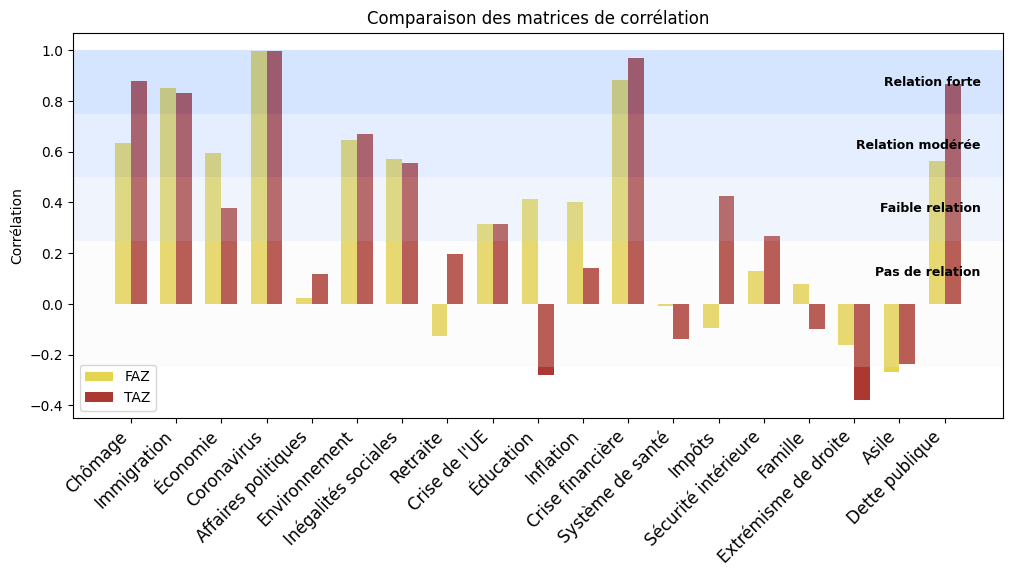

In [41]:


# Création des indices sous forme de catégories
indices = np.arange(len(corr_df))
width = 0.35  

# actual data
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(indices - width/2, corr_df["FAZ"], width=width, label="FAZ", color='#E5D352') 
ax.bar(indices + width/2, corr_df["TAZ"], width=width, label="TAZ", color='#AC3931')   

# zones de corrélation
ax.axhspan(-0.25, 0.25, facecolor='#f0f0f0', alpha=0.2)
ax.axhspan(0.25, 0.5, facecolor='#d0e1f9', alpha=0.3)
ax.axhspan(0.5, 0.75, facecolor='#a6c8ff', alpha=0.3)
ax.axhspan(0.75, 1.0, facecolor='#7aaaff', alpha=0.3)


# Ajouter corrélations
ax.text(len(indices) - 0.2, 0.125, 'Pas de relation', va='center', ha='right', fontsize=9, fontweight='bold')
ax.text(len(indices) - 0.2, 0.375, 'Faible relation', va='center', ha='right', fontsize=9, fontweight='bold')
ax.text(len(indices) - 0.2, 0.625, 'Relation modérée', va='center', ha='right', fontsize=9, fontweight='bold')
ax.text(len(indices) - 0.2, 0.875, 'Relation forte', va='center', ha='right', fontsize=9, fontweight='bold')


ax.set_xticks(indices)
ax.set_xticklabels(corr_df.index, fontsize=12,rotation=45,ha="right")  # Affichage des indices distincts

ax.set_ylabel("Corrélation")
ax.set_title("Comparaison des matrices de corrélation")
ax.legend()
plt.savefig('../report/images/article_sondages_corr.pdf',bbox_inches='tight')

plt.show()


### Fisher's Test pour déterminer l'indépendance des variables

In [42]:
for idx in keywords_fr.keys():
    import scipy.stats as stats 
    df_test = dfs_faz_all[idx].copy().reset_index()
    df_test['survey'] = df_survey.reset_index()[idx]
    df_test = df_test.dropna()
    print(keywords_fr[idx])
    #print(df_test[[idx,'survey']])
    print(stats.fisher_exact(df_test).pvalue)
    print("---------------")

Retraite
0.214
---------------
Inflation
1.0
---------------
Impôts
0.6559
---------------
Économie
0.9572
---------------
Chômage
0.18
---------------
Environnement
0.3965
---------------
Famille
0.3431
---------------
Système de santé
1.0
---------------
Sécurité intérieure
0.9075
---------------
Affaires politiques
0.1292
---------------
Éducation
0.8106
---------------
Asile
0.7384
---------------
Immigration
0.7875
---------------
Crise de l'UE
0.9555
---------------
Dette publique
0.6062
---------------
Extrémisme de droite
0.6
---------------
Inégalités sociales
1.0
---------------
Crise financière
0.4377
---------------
Coronavirus
0.9579
---------------


In [43]:
df_survey

# copy the data 
df_max_scaled = df_survey.copy() 
  
# apply normalization techniques 
for column in df_max_scaled.columns: 
    if column == 'Year':
        pass
    df_max_scaled[column] = df_max_scaled[column]  / df_max_scaled[column].abs().max() 
      
# view normalized data 
display(df_max_scaled) 


,14,54,13,134,27,15,77,1,55,66,30,5,117,20,10,23,19,58,53,56
Year,,,,,,,,,,,,,,,,,,,,
2000,0.754530,0.058254,0.088108,0.000000,0.786906,0.063331,0.080150,0.544819,0.008422,0.371627,0.118511,0.037210,0.000000,0.160332,0.870582,0.389684,0.272857,1.000000,0.464232,0.089133
2001,0.782928,0.043825,0.214002,0.000000,0.612339,0.057621,0.082605,0.368165,0.071735,0.328075,0.167140,0.044381,0.000000,0.222331,0.439152,0.546123,0.342911,0.618099,0.309391,0.057810
2002,0.913608,0.025733,0.347875,0.000000,0.541253,0.027394,0.060582,0.120611,0.044937,0.272695,0.199523,0.037765,0.000000,0.116334,0.660325,0.115830,0.266607,0.045488,0.085379,0.142042
2003,0.853681,0.007594,0.468369,0.000000,0.671002,0.008566,0.064996,0.388593,0.000244,0.409794,0.112771,0.021607,0.000000,0.486119,0.969802,0.033640,0.163720,0.012849,0.027601,0.282197
2004,0.867219,0.014218,0.373947,0.000000,0.704377,0.000000,0.091214,0.296435,0.003893,0.306571,0.178550,0.032176,0.000000,0.717214,0.573212,0.044714,0.208092,0.033416,0.067536,0.267799
2005,1.000000,0.007435,0.250603,0.000000,0.519557,0.009288,0.080244,0.148064,0.001907,0.187113,0.131167,0.051829,0.000000,0.109979,0.317605,0.035848,0.189001,0.015479,0.007130,0.227543
2006,0.908974,0.018818,0.165771,0.000000,0.444690,0.011403,0.118735,0.255987,0.001126,0.002263,0.245443,0.067834,0.000000,1.000000,0.763105,0.080487,0.412141,0.032653,0.000000,0.189378
2007,0.716718,0.021765,0.131267,0.000000,0.538532,0.175145,0.331050,0.373338,0.004473,0.419100,0.399417,0.180584,0.000000,0.656268,0.714469,0.160475,0.926625,0.050896,0.000000,0.139975
2008,0.441356,0.020264,0.278027,0.000000,0.750327,0.081818,0.544455,0.367905,0.001627,0.303247,0.561698,0.443485,0.631933,0.329729,1.000000,0.311066,0.617744,0.033224,0.000000,0.104614


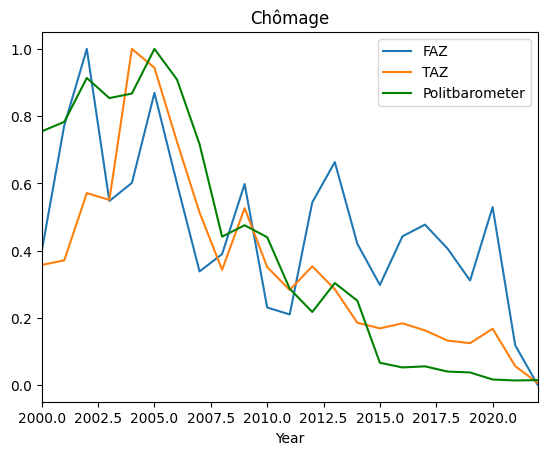

In [44]:
question_code = 14
ax = dfs_faz_all[question_code].plot(label = "FAZ")
dfs_taz_all[question_code].plot(ax=ax, label = "TAZ")
#df_survey[58] *= 10

df_max_scaled[question_code].plot(label = "Politbarometer",color='green')
plt.xlim(2000,2022)
plt.title(keywords_fr[question_code])
plt.legend()

In [96]:
df_survey[58]

Year
2000    0.040633
2001    0.021817
2002    0.002202
2003    0.000734
2004    0.001968
2005    0.001268
2006    0.001868
2007    0.002869
2008    0.001902
2009    0.002135
2010    0.000801
2011    0.006172
2012    0.005838
2013    0.005638
2014    0.005971
2015    0.010909
2016    0.022818
2017    0.014045
2018    0.023118
2019    0.028323
2020    0.015112
2021    0.005238
2022    0.003803
Name: 58, dtype: float64